<a href="https://colab.research.google.com/github/aditi980/Drug-analysis/blob/main/Sample_drug_analysis(2)_using_pre_trained_CNN_model_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from PIL import Image, ImageDraw, ImageFilter, ImageChops
import tensorflow as tf
from tensorflow.keras.applications.mobilenet import MobileNet, preprocess_input, decode_predictions
from scipy.spatial.distance import cdist

In [ ]:
#1. Improved Synthetic Image Generator
def create_liquid_paper_image(color_rgb, image_size=(224,224), darkness=0.2):
    # Off-white paper background
    img = Image.new("RGB", image_size, (245, 245, 235))
    ellipse_bounds = [
        image_size[0]*0.2, image_size[1]*0.3,
        image_size[0]*0.8, image_size[1]*0.7
    ]
    # Liquid drop ellipse and blur
    mask = Image.new("L", image_size, 0)
    mask_draw = ImageDraw.Draw(mask)
    mask_draw.ellipse(ellipse_bounds, fill=255)
    blurred_mask = mask.filter(ImageFilter.GaussianBlur(radius=5))
    # Liquid layer with strong color and noise
    dark_color = tuple(max(0, int(c * darkness)) for c in color_rgb)
    liquid_layer = Image.new("RGBA", image_size, dark_color + (0,))
    noise = Image.effect_noise(image_size, 25).point(lambda i: i * 0.5).convert("L")
    liquid_layer.putalpha(ImageChops.multiply(blurred_mask, noise))
    result = Image.alpha_composite(img.convert("RGBA"), liquid_layer)
    # Shadow for realism
    shadow = Image.new("RGBA", image_size, (0,0,0,0))
    shadow_draw = ImageDraw.Draw(shadow)
    shadow_draw.ellipse([
        ellipse_bounds[0]+3, ellipse_bounds[1]+5,
        ellipse_bounds[2]+3, ellipse_bounds[3]+5
    ], fill=(0,0,0,90))
    shadow = shadow.filter(ImageFilter.GaussianBlur(4))
    result = Image.alpha_composite(shadow, result)
    return result.convert("RGB")

In [ ]:
#2. Definitions
drug_names = ['Paracetamol', 'Ibuprofen', 'Naproxen']
labels = ['A', 'B', 'C']
matrix = np.array([
    [12, 7, 5],    # Paracetamol
    [18, 9, 8],    # Ibuprofen
    [14,12, 9],    # Naproxen
])
liquid_colors = {
    'Paracetamol': (235, 0, 0),   # red
    'Ibuprofen'  : (0, 235, 0),   # green
    'Naproxen'   : (0, 0, 235)    # blue
}

# Show amounts matrix
print('Drug Amounts Matrix:')
print(f'|{"":12}|{labels[0]:^6}|{labels[1]:^6}|{labels[2]:^6}|')
for i, drug in enumerate(drug_names):
    print(f'|{drug:12}|{matrix[i,0]:^6}|{matrix[i,1]:^6}|{matrix[i,2]:^6}|')

Drug Amounts Matrix:
|            |  A   |  B   |  C   |
|Paracetamol |  12  |  7   |  5   |
|Ibuprofen   |  18  |  9   |  8   |
|Naproxen    |  14  |  12  |  9   |


In [ ]:
#3. Generate Realistic 3x3 Synthetic Images
IMG_SIZE = 224  # MobileNet's preferred input
images = []
for drug in drug_names:
    for label in labels:
        img = create_liquid_paper_image(liquid_colors[drug], image_size=(IMG_SIZE, IMG_SIZE), darkness=0.2)
        images.append((img, drug, label))

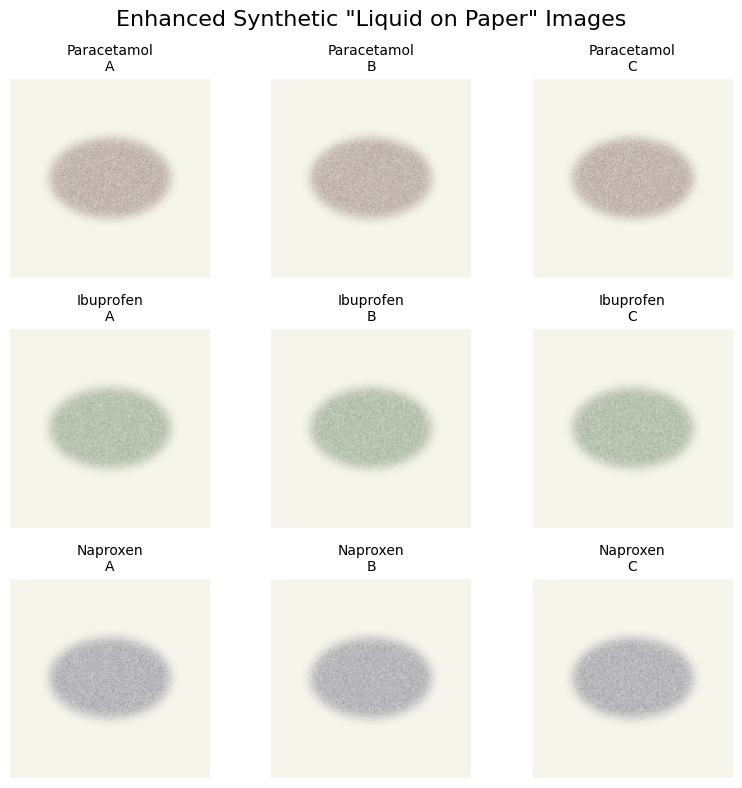

In [ ]:
#4. Display the 3x3 grid of synthetic images
fig, axs = plt.subplots(3, 3, figsize=(8, 8))
plt.suptitle('Enhanced Synthetic "Liquid on Paper" Images', fontsize=16)
for idx, ax in enumerate(axs.flatten()):
    img, drug, label = images[idx]
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"{drug}\n{label}", fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
#5. Preprocess images for MobileNet
mobilenet = MobileNet(weights='imagenet', include_top=True)
mobilenet_feat = MobileNet(weights='imagenet', include_top=False, pooling='avg')

imgs_ready = []
for img, _, _ in images:
    arr = np.array(img).astype(np.float32)  # (224,224,3)
    arr = preprocess_input(arr)  # Preprocessing for MobileNet
    imgs_ready.append(arr)
imgs_ready = np.stack(imgs_ready)  # (9, 224, 224, 3)

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/tmp/ipython-input-3528829699.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_feat = MobileNet(weights='imagenet', include_top=False, pooling='avg')


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
#6. Get predictions and feature embeddings
preds = mobilenet.predict(imgs_ready)
top_labels = decode_predictions(preds, top=1)
print("\nMobileNet Predictions for Each Synthetic Image:")
for idx, (img, drug, label) in enumerate(images):
    decoded = top_labels[idx][0]
    print(f"{drug}-{label}: {decoded[1]} (class {decoded[0]}) - score {decoded[2]:.3f}")

embeddings = mobilenet_feat.predict(imgs_ready)  # (9, 1024)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

MobileNet Predictions for Each Synthetic Image:
Paracetamol-A: hourglass (class n03544143) - score 0.092
Paracetamol-B: face_powder (class n03314780) - score 0.108
Paracetamol-C: face_powder (class n03314780) - score 0.079
Ibuprofen-A: pick (class n03929660) - score 0.106
Ibuprofen-B: pick (class n03929660) - score 0.105
Ibuprofen-C: pick (class n03929660) - score 0.088
Naproxen-A: spotlight (class n04286575) - score 0.161
Naproxen-B: matchstick (class n03729826) - score 0.219
Naproxen-C: matchstick (class n03729826) - score 0.103
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


In [ ]:
#7. Per-drug embedding (average over three positions)
drug_embeds = []
for i in range(3):
    grp = embeddings[i*3:(i+1)*3]
    drug_embeds.append(np.mean(grp, axis=0))
drug_embeds = np.stack(drug_embeds)  # (3, 1024)

In [ ]:
#8. Calculate embedding-based and data-based distance matrice
distance_matrix_embed = cdist(drug_embeds, drug_embeds, 'euclidean')
distance_df_embed = pd.DataFrame(distance_matrix_embed, columns=drug_names, index=drug_names)

def euclidean_distance(v1, v2):
    return np.linalg.norm(np.array(v1) - np.array(v2))
distance_matrix_data = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        distance_matrix_data[i, j] = euclidean_distance(matrix[i], matrix[j])
distance_df_data = pd.DataFrame(distance_matrix_data, columns=drug_names, index=drug_names)

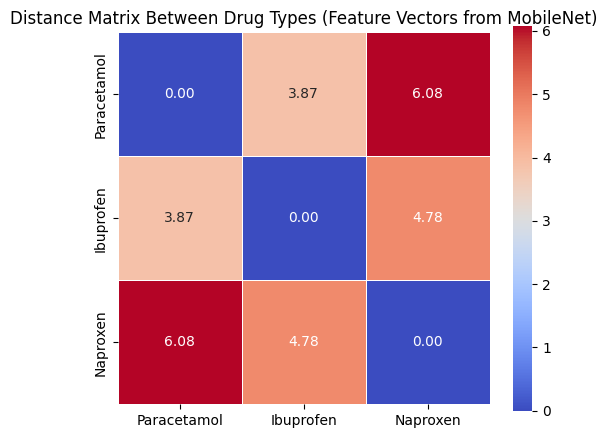

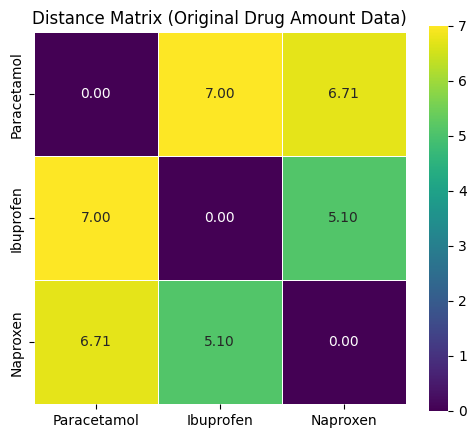

In [ ]:
#9. Show both matrices as heatmaps
plt.figure(figsize=(6,5))
sns.heatmap(distance_df_embed, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=.5)
plt.title('Distance Matrix Between Drug Types (Feature Vectors from MobileNet)')
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(distance_df_data, annot=True, cmap='viridis', fmt=".2f", square=True, linewidths=.5)
plt.title('Distance Matrix (Original Drug Amount Data)')
plt.show()

In [ ]:
#10. Print both distance matrices
print('\nPairwise Euclidean Distance Matrix (using MobileNet embeddings average):')
print(distance_df_embed)
print('\nPairwise Euclidean Distance Matrix (using original data amounts):')
print(distance_df_data)


Pairwise Euclidean Distance Matrix (using MobileNet embeddings average):
             Paracetamol  Ibuprofen  Naproxen
Paracetamol     0.000000   3.869040  6.081524
Ibuprofen       3.869040   0.000000  4.778093
Naproxen        6.081524   4.778093  0.000000

Pairwise Euclidean Distance Matrix (using original data amounts):
             Paracetamol  Ibuprofen  Naproxen
Paracetamol     0.000000    7.00000  6.708204
Ibuprofen       7.000000    0.00000  5.099020
Naproxen        6.708204    5.09902  0.000000


In [ ]:
# Values from matrix
paracetamol = [12, 7, 5]
ibuprofen   = [18, 9, 8]
naproxen    = [14, 12, 9]

print("Paracetamol A - Ibuprofen A:", abs(paracetamol[0] - ibuprofen[0]))
print("Paracetamol A - Naproxen A:", abs(paracetamol[0] - naproxen[0]))
print("Paracetamol B - Ibuprofen B:", abs(paracetamol[1] - ibuprofen[1]))
print("Paracetamol B - Naproxen B:", abs(paracetamol[1] - naproxen[1]))
print("Paracetamol C - Ibuprofen C:", abs(paracetamol[2] - ibuprofen[2]))
print("Paracetamol C - Naproxen C:", abs(paracetamol[2] - naproxen[2]))


Paracetamol A - Ibuprofen A: 6
Paracetamol A - Naproxen A: 2
Paracetamol B - Ibuprofen B: 2
Paracetamol B - Naproxen B: 5
Paracetamol C - Ibuprofen C: 3
Paracetamol C - Naproxen C: 4


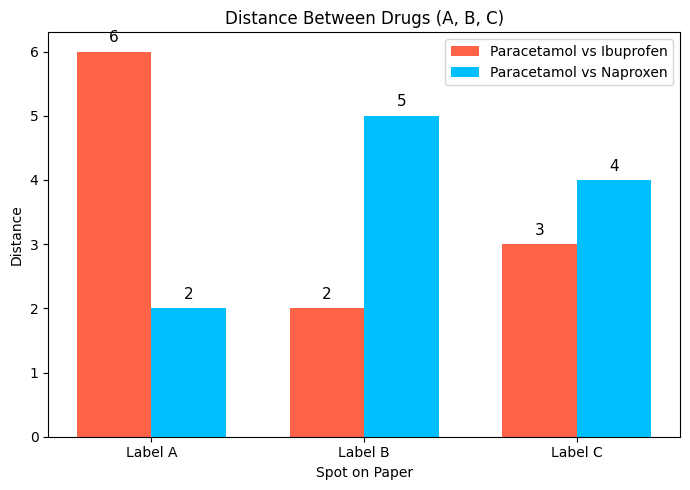

In [ ]:
# Data: values at each spot for each drug
drug_data = {
    'Paracetamol': [12, 7, 5],   # A, B, C
    'Ibuprofen'  : [18, 9, 8],   # A, B, C
    'Naproxen'   : [14, 12, 9]   # A, B, C
}
labels = ['A', 'B', 'C']

# Calculate distances for each label
dist_par_ib = [abs(a - b) for a, b in zip(drug_data['Paracetamol'], drug_data['Ibuprofen'])]
dist_par_nap = [abs(a - n) for a, n in zip(drug_data['Paracetamol'], drug_data['Naproxen'])]

# Set up the plot
x = np.arange(len(labels))
width = 0.35  # width of bars

plt.figure(figsize=(7,5))
bars1 = plt.bar(x - width/2, dist_par_ib, width, label='Paracetamol vs Ibuprofen', color='tomato')
bars2 = plt.bar(x + width/2, dist_par_nap, width, label='Paracetamol vs Naproxen', color='deepskyblue')

# Add labels and title
plt.xticks(x, [f'Label {lbl}' for lbl in labels])
plt.ylabel('Distance')
plt.xlabel('Spot on Paper')
plt.title('Distance Between Drugs (A, B, C)')
plt.legend()

# Annotate values on bars
def annotate_bars(bars):
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval), ha='center', va='bottom', fontsize=11)

annotate_bars(bars1)
annotate_bars(bars2)

plt.tight_layout()
plt.show()